# Optimized Spam Detection System

## Project Overview

This project develops an end-to-end spam detection system using Natural Language Processing (NLP) and Machine Learning techniques.

The project starts with data exploration and preprocessing, transforms raw SMS messages into numerical features using TF-IDF, and prepares the data for training and evaluating machine learning classification models.

## Import Required Libraries

In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import scipy.sparse as sp

import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

%matplotlib inline

## Load the Dataset

The SMS Spam Collection dataset is loaded into a Pandas DataFrame to begin the data exploration and preprocessing stages.

In [28]:
df = pd.read_csv("../data/spam.csv", encoding="latin1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Dataset Overview

In [29]:
df.shape

(5572, 5)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [31]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

### Observations

- The dataset contains five columns.
- Only `v1` and `v2` contain useful information.
- Columns `Unnamed: 2`, `Unnamed: 3`, and `Unnamed: 4` contain only missing values and do not contribute to the analysis.
- These unnecessary columns will be removed during the data cleaning stage.

In [32]:
# Remove unnecessary columns
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)

# Rename columns
df.rename(columns={
    "v1": "label",
    "v2": "message"
}, inplace=True)

# Display the updated dataset
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


### Observations

- The unnecessary columns containing only missing values were removed.
- The remaining columns were renamed to `label` and `message` for better readability.
- The cleaned dataset contains **5,572 SMS messages** and **2 columns**.
- Both columns are stored as text (`object`) and will be processed during the NLP preprocessing stage.

### Check for Missing Values

In [34]:
df.isnull().sum()

label      0
message    0
dtype: int64

### Observations

- No missing values were found in the dataset.
- Both the `label` and `message` columns are complete.
- Since there are no missing values, no imputation or row removal is required.
- The dataset is ready for the next cleaning step.

### Check for Duplicate Records

Duplicate records may bias the model during training by giving more weight to repeated messages. Therefore, the dataset is checked for duplicate entries before proceeding with preprocessing.

In [35]:
df.duplicated().sum()

403

### Remove Duplicate Records

In [36]:
df.drop_duplicates(inplace=True)

df.reset_index(drop=True, inplace=True)

df.shape

(5169, 2)

### Observations

- The dataset originally contained **403 duplicate records**.
- Duplicate messages were removed to improve data quality and reduce the risk of overfitting.
- After removing duplicates, the dataset contains **5,169 unique SMS messages** and **2 columns**.
- The index was reset to maintain a clean and continuous row numbering.

# Exploratory Data Analysis (EDA)

## Distribution of Spam and Ham Messages
  This helps determine whether the dataset is balanced or imbalanced.

In [37]:
# Count the number of messages in each class
class_distribution = df["label"].value_counts()

class_distribution

label
ham     4516
spam     653
Name: count, dtype: int64

### Observations

- The dataset contains **4,516 ham messages** and **653 spam messages**.
- The classes are **imbalanced**, with ham messages representing the majority of the dataset.
- This imbalance should be considered during model evaluation, as relying solely on accuracy may produce misleading results.

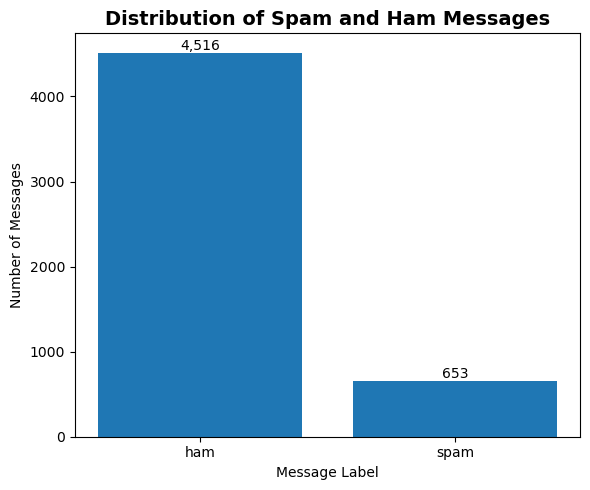

In [38]:
plt.figure(figsize=(6, 5))

bars = plt.bar(
    class_distribution.index,
    class_distribution.values
)

plt.title("Distribution of Spam and Ham Messages",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Message Label")
plt.ylabel("Number of Messages")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("../outputs/figures/class_distribution.png", dpi=300)

plt.show()

### Class Distribution Insights

The dataset contains 4,516 ham messages and 653 spam messages. This shows a clear class imbalance, with ham messages representing the majority of the dataset. Therefore, model evaluation should consider metrics such as precision, recall, and F1-score in addition to accuracy.

In [39]:
df["message_length"] = df["message"].str.len()

df[["label", "message", "message_length"]].head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


### Message Length Feature

The `message_length` feature represents the number of characters in each SMS message. This feature can help identify differences in message length between spam and ham messages.

In [40]:
df.groupby("label")["message_length"].mean()

label
ham      70.459256
spam    137.891271
Name: message_length, dtype: float64

### Message Length Insights

The average ham message length is approximately 70 characters, while the average spam message length is approximately 138 characters.

This indicates that spam messages tend to be longer than ham messages in this dataset. However, message length alone is not sufficient to classify a message as spam, so it will be considered as one feature among several others.

## Message Length Distribution by Class

This provides more information than the average alone by showing the spread and potential outliers within each class.

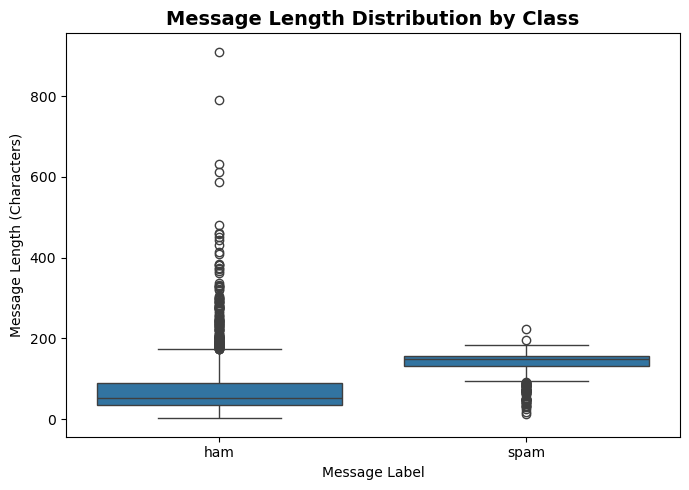

In [41]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="label",
    y="message_length"
)

plt.title(
    "Message Length Distribution by Class",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Message Label")
plt.ylabel("Message Length (Characters)")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/message_length_by_class.png",
    dpi=300
)

plt.show()

### Message Length Insights

The analysis shows that spam messages tend to be longer than ham messages. The average ham message length is approximately 70 characters, while the average spam message length is approximately 138 characters.

The boxplot also shows a wider range of message lengths and several outliers, particularly among ham messages. Message length may therefore provide useful information for distinguishing between spam and ham messages.

## Word Count Analysis

In addition to character length, the number of words in each message is examined. Word count provides another numerical feature that may help describe differences between spam and ham messages.

In [42]:
df["word_count"] = df["message"].str.split().str.len()

df[["label", "message", "word_count"]].head()

,label,message,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",20
1,ham,Ok lar... Joking wif u oni...,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,ham,U dun say so early hor... U c already then say...,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",13


### Word Count Feature

The `word_count` feature represents the number of words contained in each SMS message. Together with `message_length`, it provides additional information about the structure of the messages and may help distinguish between spam and ham.

In [43]:
df.groupby("label")["word_count"].mean()

label
ham     14.134632
spam    23.681470
Name: word_count, dtype: float64

### Word Count Insights

The average word count is approximately 14 words for ham messages and 24 words for spam messages. This indicates that spam messages tend to contain more words than ham messages in this dataset.

Word count may therefore provide additional information for distinguishing between the two classes, although it should not be used alone for classification.

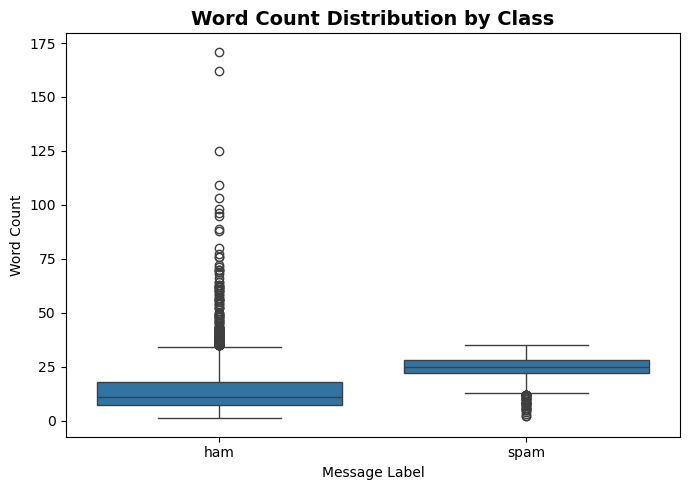

In [44]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.title("Word Count Distribution by Class",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Message Label")
plt.ylabel("Word Count")

plt.tight_layout()

plt.savefig("../outputs/figures/word_count_distribution.png", dpi=300)

plt.show()

### Word Count Insights

The boxplot shows that spam messages generally contain more words than ham messages. The average word count is approximately 14 words for ham messages and 24 words for spam messages.

The distributions also contain outliers, particularly for ham messages, showing that some legitimate messages can be considerably longer. Therefore, word count can provide useful supporting information for classification but should not be used as a standalone feature.

# Text Preprocessing

Text preprocessing transforms raw SMS messages into a cleaner and more consistent representation that can be used for feature extraction and machine learning.

The preprocessing pipeline will include:
- Converting text to lowercase
- Removing punctuation and unnecessary characters
- Tokenizing the text
- Removing stopwords
- Applying stemming

In [45]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ayawa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ayawa\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayawa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

### Text Cleaning and Normalization

A preprocessing function is created to apply the same transformations consistently to every message. The function converts text to lowercase, removes punctuation and non-alphabetic characters, tokenizes the message, removes English stopwords, and applies stemming.

In [52]:
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Replace punctuation with spaces
    text = text.translate(
        str.maketrans(string.punctuation, " " * len(string.punctuation))
    )

    # Keep letters, numbers, and spaces
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove extra whitespace tokens
    tokens = [word for word in tokens if word.strip()]

    # Apply stemming
    tokens = [
        stemmer.stem(word)
        for word in tokens
    ]

    # Join tokens back into a single string
    return " ".join(tokens)

In [53]:
sample_message = df["message"].iloc[2]

print("Original:")
print(sample_message)

print("\nPreprocessed:")
print(preprocess_text(sample_message))

Original:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Preprocessed:
free entri in 2 a wkli comp to win fa cup final tkt 21st may 2005 text fa to 87121 to receiv entri question std txt rate t c s appli 08452810075over18 s


## Apply Text Preprocessing

After validating the preprocessing function on a sample message, the same preprocessing pipeline is applied to the complete dataset. The original `message` column is preserved, while the processed text is stored in a new `processed_message` column.

In [54]:
df["processed_message"] = df["message"].apply(preprocess_text)

df[["label", "message", "processed_message"]].head()

,label,message,processed_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazi avail onli in bugi...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri in 2 a wkli comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,u dun say so earli hor u c alreadi then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goe to usf he live around...


### Preprocessing Result

The preprocessing pipeline was successfully applied to all messages. The original `message` column was preserved, while the processed text was stored in `processed_message`.

This approach keeps the raw data available for reference while providing a cleaned text representation for downstream NLP feature extraction.

## Validate Processed Text

After preprocessing, the processed messages are checked for empty values to ensure that the transformation did not remove all meaningful text from any records.

In [55]:
empty_processed = (df["processed_message"].str.strip() == "").sum()

empty_processed

2

In [56]:
df.loc[
    df["processed_message"].str.strip() == "",
    ["label", "message"]
]

,label,message
3191,ham,:)
4500,ham,:-) :-)


### Handle Empty Processed Messages

After refining the preprocessing pipeline, only two messages resulted in empty processed text. Both messages consist entirely of emoticons and contain no textual content for the current TF-IDF pipeline. These records are removed before feature extraction.

In [57]:
# Remove messages with no remaining processed text
df = df[df["processed_message"].str.strip() != ""].copy()

# Reset the index
df.reset_index(drop=True, inplace=True)

# Verify the result
df.shape

(5167, 5)

In [58]:
df["processed_message"].str.strip().eq("").sum()

0

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5167 entries, 0 to 5166
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   label              5167 non-null   object
 1   message            5167 non-null   object
 2   message_length     5167 non-null   int64 
 3   word_count         5167 non-null   int64 
 4   processed_message  5167 non-null   object
dtypes: int64(2), object(3)
memory usage: 202.0+ KB


## Save Cleaned Dataset

The cleaned and preprocessed dataset is saved as an output file so that the downstream machine learning pipeline can use it directly without repeating the data cleaning and preprocessing steps.

In [60]:
df.to_csv("../outputs/cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [61]:
import os

os.path.exists("../outputs/cleaned_dataset.csv")

True

## TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts the processed text into numerical features.

It gives higher importance to words that are frequent in a specific message but less common across the entire dataset. These numerical features will be used by the downstream machine learning models for spam classification.

In [63]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [64]:
X_tfidf = tfidf.fit_transform(df["processed_message"])

X_tfidf.shape

(5167, 5000)

### TF-IDF Feature Matrix

The processed SMS messages were transformed into a TF-IDF feature matrix using unigrams and bigrams. The resulting matrix contains 5,167 messages and 5,000 text features.

This numerical representation can be passed to the machine learning models for spam classification.

In [66]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["label"])

y[:10]

array([0, 0, 1, 0, 0, 1, 0, 0, 1, 1])

In [67]:
dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
))

{'ham': 0, 'spam': 1}

### Target Label Encoding

The target labels were encoded into numerical values for machine learning. The encoding is:

- Ham → 0
- Spam → 1

The encoded labels correspond to the same message order as the TF-IDF feature matrix.

In [69]:
sp.save_npz("../outputs/tfidf_features.npz", X_tfidf)

In [70]:
np.save("../outputs/labels.npy", y)

In [71]:
feature_names = tfidf.get_feature_names_out()

pd.Series(feature_names).to_csv(
    "../outputs/tfidf_feature_names.csv",
    index=False,
    header=["feature"]
)

In [72]:
# Validate saved TF-IDF features and labels

X_loaded = sp.load_npz("../outputs/tfidf_features.npz")
y_loaded = np.load("../outputs/labels.npy")

print("TF-IDF shape:", X_loaded.shape)
print("Labels shape:", y_loaded.shape)
print("Number of features:", len(feature_names))

TF-IDF shape: (5167, 5000)
Labels shape: (5167,)
Number of features: 5000


In [73]:
assert X_loaded.shape[0] == len(y_loaded)
assert X_loaded.shape[1] == len(feature_names)

print("Validation passed successfully.")

Validation passed successfully.


# Data & NLP Pipeline Handoff

The Data & NLP pipeline prepares the cleaned SMS dataset and transforms the processed text into numerical TF-IDF features for the machine learning stage.

## Final Dataset

- 5,167 cleaned messages
- 0 empty processed messages
- Ham: 0
- Spam: 1

## Generated Features

- `message_length`
- `word_count`
- TF-IDF features using unigrams and bigrams
- 5,000 TF-IDF features

## Output Files

- `outputs/cleaned_dataset.csv` — cleaned and preprocessed dataset
- `outputs/tfidf_features.npz` — sparse TF-IDF feature matrix
- `outputs/tfidf_feature_names.csv` — TF-IDF feature names
- `outputs/labels.npy` — encoded target labels

The machine learning stage can load these outputs directly for model training and evaluation.m

- Label encoding: Ham → 0, Spam → 1